# METAR Data Collection and AROME-METAR Fusion: Diagnostics and Coverage Analysis

This notebook documents the diagnostic work carried out while building the METAR observation dataset for the 26 Moroccan WMO synoptic stations (2021-2025) and merging it with the AROME numerical weather prediction output. It is organized as a research log rather than a polished pipeline: each section records a specific question that was investigated, the code used to answer it, and the conclusion that followed. Several of these investigations exposed bugs or coverage gaps in earlier versions of the collection pipeline, which were subsequently fixed in the standalone scripts under `src/metar_collection/`. This notebook is the evidence trail for those fixes, and the final sections evaluate their effect on data coverage.

The overall pipeline referenced throughout is:

1. `download_noaa_isd.py` downloads NOAA Global Hourly (ISD) data for the 26 target stations.
2. `parse_noaa.py` decodes the structured ISD columns (wind, temperature, pressure, visibility, ceiling, gust) into `METAR_2021_2025.csv`, using the embedded raw METAR text (`REM` field) parsed with `avwx-engine` as a secondary enrichment for cloud layers and present weather.
3. `parse_metars_history.py` decodes a separate archive of raw METAR transmission bulletins (`metars_1.csv`, `metars_backup.csv`) into `METAR_bulletin_2021_2025.csv`, using `avwx-engine` as the primary decoder since this source has no structured columns.
4. `merge_metar_sources.py` unions the NOAA-derived and bulletin-derived datasets, with NOAA taking priority whenever both sources cover the same station and hour, and the bulletin filling in NOAA's gaps.
5. `merge_arome_metar.py` performs the final inner join between AROME grid-point output and the merged METAR dataset, on station id and hour.


## 1. Initial Diagnostic: AROME-METAR Station Matching

The first step in building the fusion was to verify that the station identifiers used on the AROME side (WMO synoptic station numbers, e.g. `60101`) and the METAR side (ICAO airport codes, e.g. `GMTT`) could be reliably mapped to one another through the station lookup table `isd_history_station_check.csv`.

Note on reproducibility: the cells in this section were run against an early version of `METAR_2021_2025.csv` that used the column names `valid` and `station` (inherited from an earlier IEM-based collection script). The current pipeline outputs `date` and `icao` instead, so re-running this section as written against the present data files will raise a `KeyError`. The section is kept unmodified because the investigation it documents is what led to discovering the bug described below; the corrected column references are already in place in `merge_arome_metar.py`.

In [15]:
import pandas as pd

arome = pd.read_csv("../data/cleaned/Arome_clean_final.csv", dtype={"id": str})
metar = pd.read_csv("../data/raw/METAR_2021_2025.csv", dtype={"station": str}, low_memory=False)
mapping = pd.read_csv("../data/cleaned/isd_history_station_check.csv", dtype=str)

arome["datetime"] = pd.to_datetime(arome["datetime"].astype(str), format="%Y%m%d%H")

metar["valid"] = pd.to_datetime(metar["valid"])
metar["datetime"] = metar["valid"].dt.floor("h")

icao_to_wmo = dict(zip(mapping["icao"], mapping["id"]))
metar["wmo_id"] = metar["station"].map(icao_to_wmo)

### 1.1 Station count and identifier overlap

A first sanity check: how many distinct stations appear on each side, and do the two ID sets actually overlap once mapped through the lookup table.

In [16]:
print(arome["id"].nunique())
print(metar["wmo_id"].nunique())
print(sorted(arome["id"].unique()))
print(sorted(metar["wmo_id"].dropna().unique()))

26
20
['60033', '60060', '60096', '60101', '60107', '60115', '60120', '60135', '60136', '60141', '60150', '60155', '60156', '60160', '60191', '60200', '60210', '60220', '60230', '60250', '60252', '60265', '60280', '60285', '60338', '60340']
['60033', '60101', '60107', '60115', '60135', '60141', '60150', '60155', '60156', '60191', '60200', '60210', '60220', '60230', '60252', '60265', '60280', '60285', '60338', '60340']


### 1.2 Temporal coverage of each dataset

Confirming that both datasets span a comparable time range before investigating station-level mismatches, so that any missing stations found below cannot be explained by a simple date-range mismatch.

In [17]:
print(arome["datetime"].min(), arome["datetime"].max())
print(metar["datetime"].min(), metar["datetime"].max())

2019-01-01 21:00:00 2025-12-31 23:00:00
2021-01-01 00:00:00 2025-12-30 23:00:00


### 1.3 Identifying AROME stations absent from the mapped METAR data

Set difference between the AROME station IDs and the METAR station IDs (after mapping through ICAO to WMO id). A non-empty result here means some AROME stations have zero matching METAR rows once mapped, which is the first sign of a problem, either in station coverage or in the mapping logic itself.

In [19]:
set(arome["id"]) - set(metar["wmo_id"].dropna())

{'60060', '60096', '60120', '60136', '60160', '60250'}

### 1.4 Looking up the missing stations in the mapping table

Checking whether the missing WMO ids are present and marked as `found` in the station lookup table. If they are present here but absent from the previous step's result, the mapping table itself is not the problem, the issue must be further downstream, in how the METAR side of the join is built.

In [20]:
mapping[mapping["id"].isin(["60060","60096","60120","60136","60160","60250"])]

,id,found,coord_match,icao,station_name,lat_arome,lon_arome,lat_isd,lon_isd,begin,end
1,60060,True,True,GMMF,SIDI IFNI,29.35,-10.175,29.369,-10.18,19500310,20250824
2,60096,True,True,GSVO,VILLA CISNEROS(MIL),23.7,-15.85,23.7,-15.867,19310103,20250404
6,60120,True,True,GMMP,KENITRA (RMAFB),34.3,-6.6,34.3,-6.6,19490122,20250824
8,60136,True,True,GMSL,SIDI SLIMANE,34.225,-6.05,34.233,-6.05,19510901,20210612
13,60160,True,True,GMFI,IFRANE,33.5,-5.15,33.505,-5.153,19490209,19971221
19,60250,True,True,GMAA,INEZGANE,30.375,-9.55,30.381,-9.546,19450615,20250824


### 1.5 Root cause: verifying whether the missing ICAO codes actually occur in the METAR data

This cell is the key diagnostic. It filters the METAR dataframe's `station` column directly against the list of missing ICAO codes. At the time this was run, the result was an empty count for every one of them, despite these stations being present and correctly flagged in the mapping table. This ruled out both a coverage gap and a mapping table error, and pointed to the join column itself: the `station` column in the METAR file being used here did not actually contain ICAO codes. It held the raw ISD station identifier (`USAF`+`WBAN` concatenated, e.g. `60338099999`), a leftover from the underlying NOAA source format. Mapping this column through an ICAO-to-WMO dictionary therefore produced `NaN` for every row, which explains the artificial "missing stations" observed in section 1.3.

This is the same class of bug later documented and fixed explicitly in `merge_arome_metar.py`, where the join was changed to use the dataset's dedicated `icao` column instead of `station`.

In [21]:
missing_icao = ["GMMF", "GSVO", "GMMP", "GMSL", "GMFI", "GMAA"]

metar[metar["station"].isin(missing_icao)]["station"].value_counts()

Series([], Name: count, dtype: int64)

### 1.6 Confirming the ICAO-to-WMO lookup table is complete and correctly structured

A final check on the mapping table itself, independent of the METAR data, to confirm the `icao` and `id` (WMO number) columns are consistent and usable once the actual join key bug (section 1.5) is fixed.

In [26]:
mapping[["icao", "id"]]

,icao,id
0,GMML,60033
1,GMMF,60060
2,GSVO,60096
3,GMTT,60101
4,GMTA,60107
5,GMFO,60115
6,GMMP,60120
7,GMME,60135
8,GMSL,60136
9,GMFF,60141


## 2. Completeness of the Raw METAR Text Field in the NOAA Archive

`parse_noaa.py` uses two complementary decoding paths: the structured ISD columns (`WND`, `TMP`, `DEW`, `SLP`, `VIS`, `CIG`, `OC1`) as the primary, fully-covered source, and the raw METAR text embedded in the `REM` column, parsed with `avwx-engine`, as an enrichment layer for cloud cover and present weather codes.

Before relying on this enrichment, it is worth checking how often the `REM` field is actually populated in the raw NOAA download. An empty `REM` field would mean the enrichment simply cannot run for that row, independently of whether `avwx` succeeds at parsing it.

In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/NOAA_ISD_2021_2025.csv",
    usecols=["icao", "REM"],
    dtype=str,
)

empty = df["REM"].isna() | (df["REM"].str.strip() == "")
print(f"REM vide : {empty.sum():,} / {len(df):,} ({empty.mean()*100:.2f}%)")

print(df.loc[empty, "icao"].value_counts())

REM vide : 0 / 1,324,764 (0.00%)
Series([], Name: count, dtype: int64)


On the full 2021-2025 archive for the 26 stations, `REM` is populated in 100% of rows: zero empty values were found across roughly 1.32 million records. This does not guarantee that `avwx` will successfully parse every one of them (a populated field can still contain a malformed or truncated report), but it confirms that the enrichment step is not being starved of input by the NOAA archive itself.

## 3. Cross-Validation of Wind Gust Values: Instrumental Field (OC1) vs Raw METAR Text

Wind gust is decoded from the structured `OC1` field (instrumental Wind-Gust-observation, reported in m/s regardless of whether the gust made it into the human-readable report) and, separately, extracted by `avwx` from the `G` group of the raw METAR text when present (e.g. `33020G35KT`). `parse_noaa.py` keeps `OC1` as the value of record for `gust_speed_ms`, but also stores the `avwx`-derived gust and flags rows where the two disagree (`gust_mismatch`), as a data quality signal rather than a correction mechanism.

This cross-validation investigates the nature of these disagreements: are they evidence of a decoding bug, or an expected consequence of the WMO/ICAO METAR coding rule that a gust is only reported in the human-readable text when it exceeds the mean wind speed by at least 10 kt (approximately 5.14 m/s)?

In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/METAR_2021_2025.csv", parse_dates=["date"])
mism = df[df["gust_mismatch"]]

only_oc1 = mism[mism["has_gust"] == 1]       # OC1 dit rafale, avwx non
only_avwx = mism[mism["has_gust"] == 0]      # avwx dit rafale, OC1 non

print(f"OC1 seul (pas dans le texte METAR): {len(only_oc1):,}")
print(f"avwx seul (pas dans OC1): {len(only_avwx):,}")

# Hypothèse seuil OACI 10kt (~5.14 m/s) : écart rafale - vent moyen
delta = only_oc1["gust_speed_ms"] - only_oc1["wind_speed_ms"]
print(delta.describe())
print(f"Sous le seuil des 10kt (5.14 m/s): {(delta < 5.14).mean() * 100:.1f}%")

OC1 seul (pas dans le texte METAR): 19,798
avwx seul (pas dans OC1): 155
count    19798.000000
mean         3.530821
std          2.282500
min          0.500000
25%          2.100000
50%          3.100000
75%          4.600000
max         50.900000
dtype: float64
Sous le seuil des 10kt (5.14 m/s): 82.0%


On the full dataset, 19,798 rows have a gust recorded in `OC1` but absent from the parsed METAR text, against only 155 rows where the reverse occurs. For the 19,798 "OC1 only" cases, the median gust-minus-mean-wind-speed gap is 3.1 m/s, and 82% of them fall below the 5.14 m/s (10 kt) reporting threshold. This confirms the coding-rule hypothesis for the large majority of mismatches: `OC1` is measuring gusts too small to be written into the METAR text, not disagreeing with it. The remaining 18% (roughly 0.27% of the full dataset) and the 155 "avwx only" cases are treated as residual noise, small enough not to warrant further correction for this study, but retained as flagged rows (`gust_mismatch = True`) for anyone who wants to filter them out downstream.

## 4. AROME-METAR Merge Coverage, First Evaluation

With the join key bug from section 1 fixed, this section evaluates what fraction of the AROME grid-point records for each station actually find a matching METAR observation at the same hour, once the fusion (`merge_arome_metar.py`) has been run once with the NOAA-only METAR source.

In [6]:
import pandas as pd

arome = pd.read_csv("../data/cleaned/Arome_clean_final.csv", dtype={"id": str})
arome["datetime"] = pd.to_datetime(arome["datetime"], format="%Y%m%d%H")
arome = arome[(arome["datetime"] >= "2021-01-01") & (arome["datetime"] <= "2025-12-31 23:59")]

merged = pd.read_csv("../data/cleaned/AROME_METAR_merged_2021_2025.csv", dtype={"id": str}, low_memory=False)

arome_counts = arome.groupby("id").size()
merged_counts = merged.groupby("id").size()

coverage = (merged_counts / arome_counts * 100).round(1).sort_values()
print(coverage)

id
60120    13.5
60096    19.0
60250    20.7
60060    30.1
60155    53.1
60285    56.2
60200    58.8
60191    62.1
60280    67.3
60220    80.9
60033    89.1
60107    89.9
60150    90.5
60210    90.8
60265    90.9
60340    91.0
60230    91.1
60101    91.2
60115    91.2
60135    91.2
60141    91.3
60156    91.3
60252    91.3
60338    91.3
60136     NaN
60160     NaN
dtype: float64


The per-station coverage ranged from about 13% to 91%. The low end was concentrated in a small, consistent group of stations (a military airbase, several secondary regional airports, and one isolated station), while the major international airports were consistently close to 91%. This pattern, rather than a uniform shortfall across all 26 stations, motivated the station-level investigation in the next section.

## 5. Diagnosing Low-Coverage Stations: Operational Hours Hypothesis

For a handful of low-coverage stations, this cell inspects the distribution of observation hours (UTC) across the whole 2021-2025 period, to test the hypothesis that low coverage reflects a genuine operational pattern (restricted reporting hours, fixed-interval synoptic reporting) rather than a data collection problem. Anfa (`60155`), one of the higher-coverage stations, is included as a reference point for comparison.

In [7]:
import pandas as pd

merged = pd.read_csv("../data/cleaned/AROME_METAR_merged_2021_2025.csv", dtype={"id": str}, low_memory=False)

for station_id in ["60120", "60096", "60250", "60155"]:  # Kenitra, Villa Cisneros, Inezgane, Anfa (référence)
    sub = merged[merged["id"] == station_id]
    hours = pd.to_datetime(sub["date"]).dt.hour.value_counts().sort_index()
    print(f"\n--- {station_id} ---")
    print(hours)


--- 60120 ---
date
0     1424
6     1421
12    1412
18    1386
Name: count, dtype: int64

--- 60096 ---
date
0     403
1     391
2     402
4     395
5     396
6     386
7     396
8     384
10    408
11    404
12    404
13    396
14    399
16    383
17    396
18    393
19    384
20    381
22    395
23    365
Name: count, dtype: int64

--- 60250 ---
date
0      531
3      540
6     1417
9     1428
12    1411
15    1420
18    1410
21     484
Name: count, dtype: int64

--- 60155 ---
date
0        2
3        2
5       23
6     1594
7     1584
8     1591
9     1581
10    1587
11    1575
12    1582
13    1561
14    1573
15    1589
16    1571
17    1559
18    1590
19    1564
20      18
21       2
Name: count, dtype: int64


The hourly distributions confirmed three distinct operational patterns:

- Kenitra (`60120`) reports almost exclusively at 00h, 06h, 12h and 18h UTC, the standard four-times-daily synoptic reporting rhythm, rather than an hourly civil aviation schedule. Its coverage ceiling is therefore close to 4/24 (about 17%) by construction, not a data quality issue.
- Inezgane (`60250`) and Anfa (`60155`, the reference station) both show a clear day/night split, with substantially more observations between roughly 06h and 20h UTC than overnight, consistent with an airfield that scales down or suspends observations outside daytime traffic hours.
- Villa Cisneros (`60096`) shows a comparatively flat, lower-volume distribution across all hours of the day, without a clear operational cutoff. This looks less like a fixed reporting schedule and more like intermittent transmission gaps, plausibly related to the reliability of the data link from this more isolated station.

None of these patterns indicate a bug in the collection pipeline. They reflect genuine, station-specific reporting characteristics and are documented here so they can be cited directly when discussing data coverage limitations in the internship report.

## 6. Comparing METAR Data Sources: NOAA Archive vs Raw Transmission Bulletin

Following the coverage gaps identified above (particularly for Ifrane, Sidi Slimane, Kenitra and Inezgane), a second, independent METAR source was obtained: two archives of raw METAR transmission bulletins (`metars_1.csv`, covering 2023-2025, and `metars_backup.csv`, covering 2021-2023), collected from a real-time transmission feed rather than the NOAA ISD archive. This section quantifies, station by station, how the coverage of this bulletin source compares to the NOAA-derived dataset, and what the union of both sources (`merge_metar_sources.py`) adds.

The bulletin archive is not a strict improvement over NOAA: it fills several stations that NOAA had essentially no data for (Ifrane had zero NOAA-derived hourly observations against roughly 24,900 in the bulletin archive), but it is close to empty for a few stations where NOAA is comprehensive (Melilla and Casablanca-Anfa, for instance). The two sources are complementary rather than one being strictly superior, which is why the pipeline treats NOAA as the primary source and uses the bulletin only to fill hours where NOAA has nothing.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

NOAA_PATH = "../data/raw/METAR_2021_2025.csv"
BULLETIN_PATH = "../data/raw/METAR_bulletin_2021_2025.csv"
MERGED_PATH = "../data/raw/METAR_merged_sources_2021_2025.csv"
MAPPING_PATH = "../data/cleaned/isd_history_station_check.csv"

mapping = pd.read_csv(MAPPING_PATH, dtype=str)
mapping = mapping[mapping["found"].astype(str).str.lower().isin(["true", "1"])]
official_icaos = set(mapping["icao"])
icao_to_name = dict(zip(mapping["icao"], mapping["station_name"]))


def load_hourly_counts(path: str, label: str) -> pd.Series:
    df = pd.read_csv(path, usecols=["icao", "date"], dtype={"icao": str}, low_memory=False)
    df = df[df["icao"].isin(official_icaos)]
    df["hour"] = pd.to_datetime(df["date"]).dt.floor("h")
    counts = df.drop_duplicates(subset=["icao", "hour"]).groupby("icao").size()
    counts.name = label
    return counts


noaa_counts = load_hourly_counts(NOAA_PATH, "NOAA")
bulletin_counts = load_hourly_counts(BULLETIN_PATH, "Bulletin")
merged_counts = load_hourly_counts(MERGED_PATH, "Merged")

comparison = pd.concat([noaa_counts, bulletin_counts, merged_counts], axis=1).fillna(0).astype(int)
comparison = comparison.sort_values("Merged")
comparison["label"] = comparison.index + " - " + comparison.index.map(icao_to_name).fillna("")

The following figure compares, for every station, the number of distinct hourly observations available from NOAA alone, from the bulletin archive alone, and from their union.

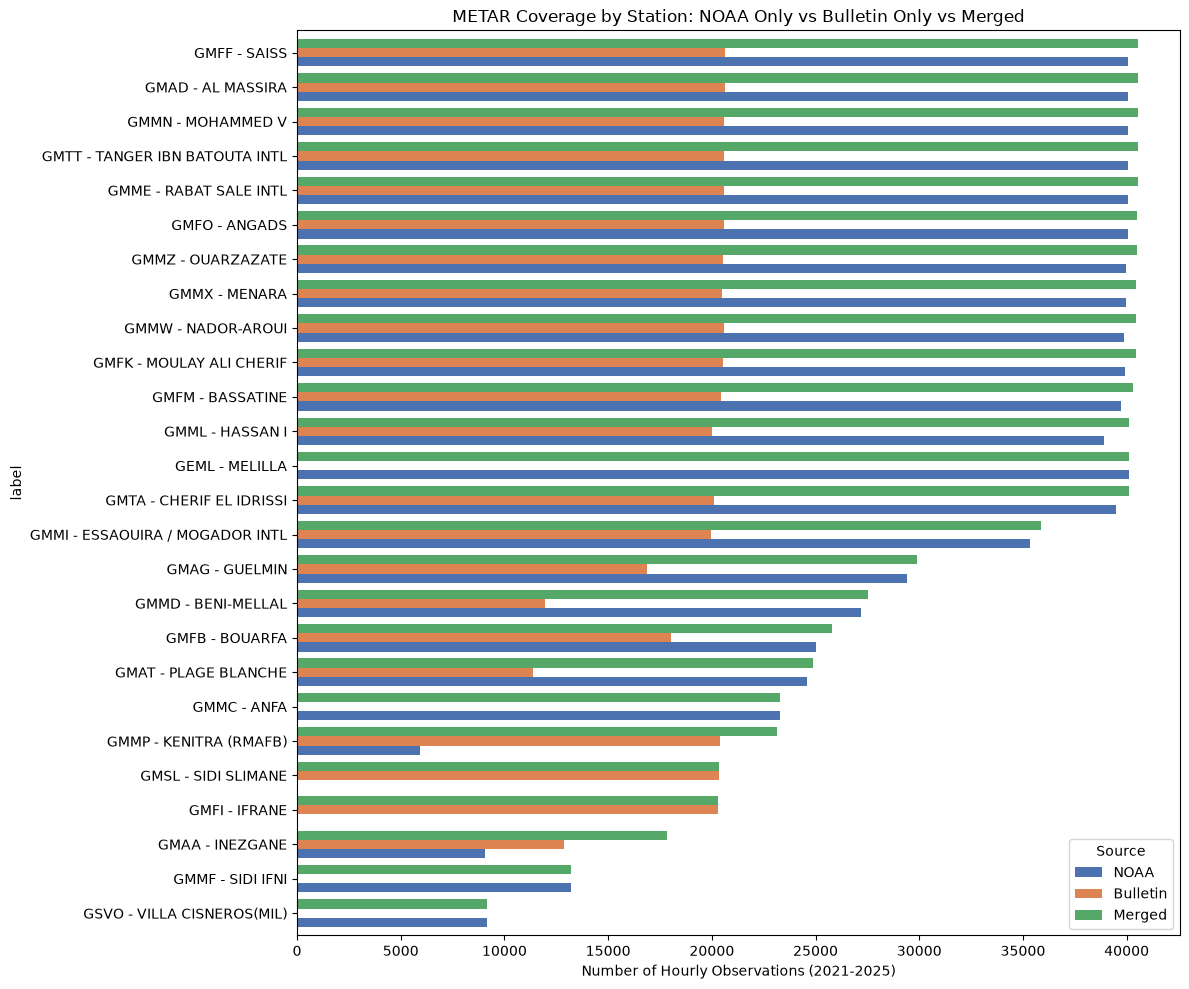

In [5]:
fig, ax = plt.subplots(figsize=(12, 10))
comparison.set_index("label")[["NOAA", "Bulletin", "Merged"]].plot(
    kind="barh", ax=ax, width=0.8,
    color={"NOAA": "#4C72B0", "Bulletin": "#DD8452", "Merged": "#55A868"}
)
ax.set_xlabel("Number of Hourly Observations (2021-2025)")
ax.set_title("METAR Coverage by Station: NOAA Only vs Bulletin Only vs Merged")
ax.legend(title="Source")
plt.tight_layout()
plt.show()

Aggregated across all 26 stations, this quantifies the net gain in usable hourly observations from adding the bulletin source on top of NOAA.

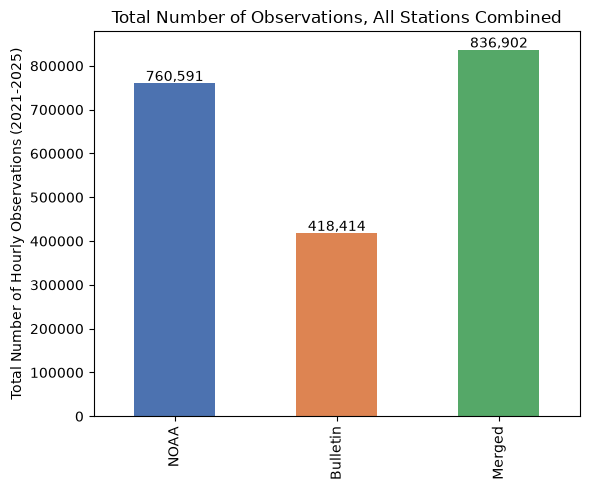

Net gain from merging sources : +76,311 observations (10.0%)


In [9]:
totals = comparison[["NOAA", "Bulletin", "Merged"]].sum()

fig, ax = plt.subplots(figsize=(6, 5))
totals.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Total Number of Hourly Observations (2021-2025)")
ax.set_title("Total Number of Observations, All Stations Combined")
for i, v in enumerate(totals):
    ax.text(i, v + 5000, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()

print(f"Net gain from merging sources : "
      f"+{totals['Merged'] - totals['NOAA']:,} observations "
      f"({(totals['Merged'] / totals['NOAA'] - 1) * 100:.1f}%)")

To make the coverage gain concrete over time rather than as a single aggregate number, the following figure plots monthly observation counts for the four stations with the largest NOAA gaps (Ifrane, Sidi Slimane, Kenitra, Inezgane), comparing the NOAA-only series against the merged series. Periods where the NOAA-only curve drops to zero while the merged curve remains populated correspond directly to the gaps closed by the bulletin source.

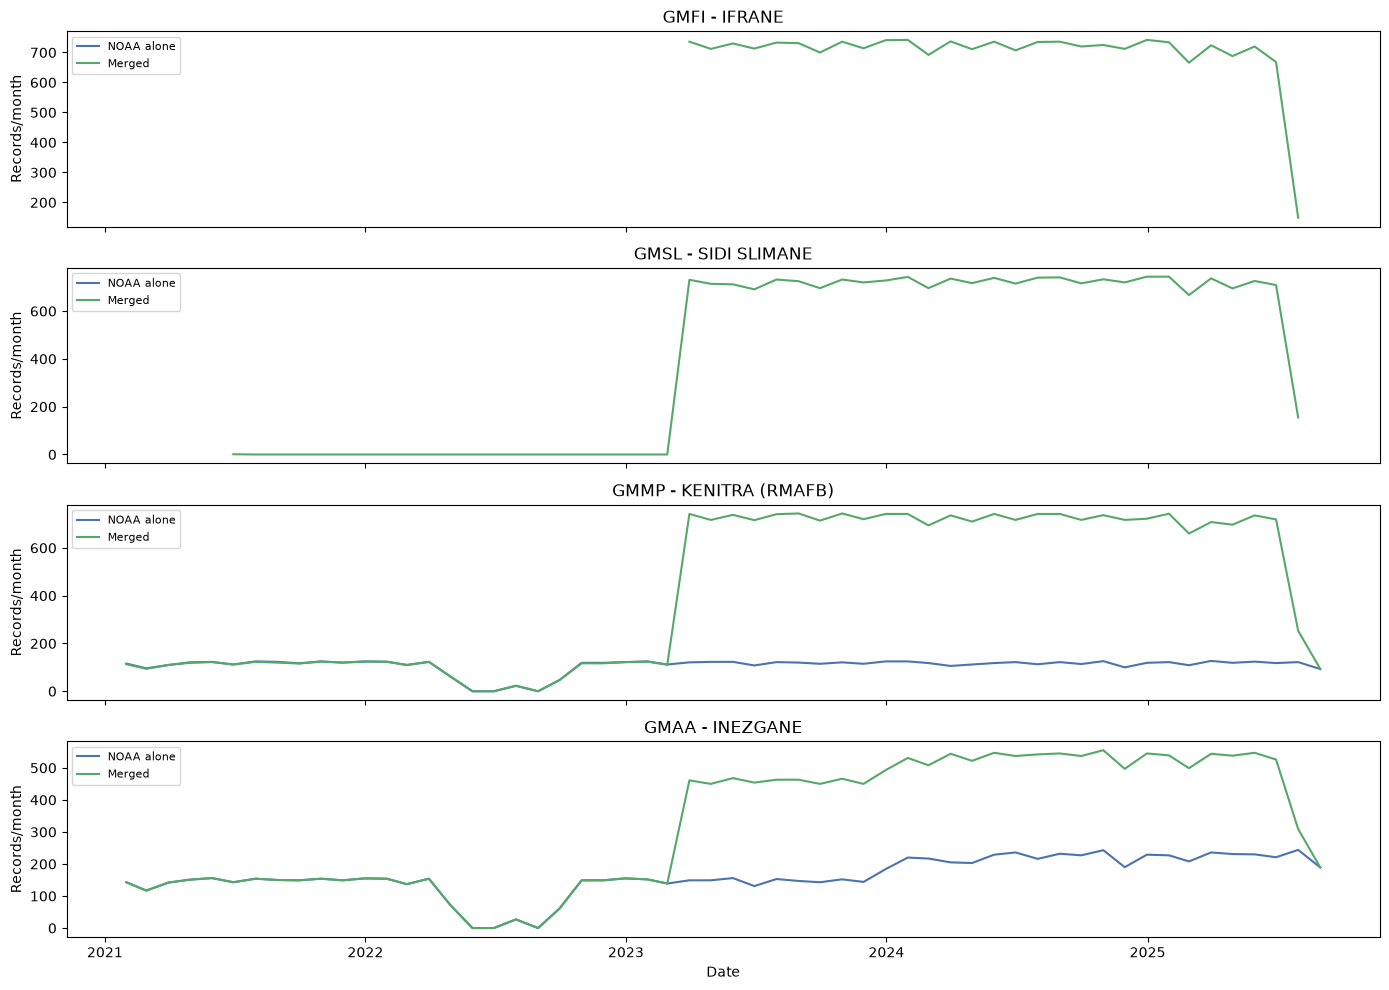

In [11]:
gap_stations = ["GMFI", "GMSL", "GMMP", "GMAA"]

noaa_df = pd.read_csv(NOAA_PATH, usecols=["icao", "date"], dtype={"icao": str}, low_memory=False)
merged_df = pd.read_csv(MERGED_PATH, usecols=["icao", "date"], dtype={"icao": str}, low_memory=False)

fig, axes = plt.subplots(len(gap_stations), 1, figsize=(14, 10), sharex=True)

for ax, icao in zip(axes, gap_stations):
    for df, label, color in [(noaa_df, "NOAA alone", "#4C72B0"), (merged_df, "Merged", "#55A868")]:
        sub = df[df["icao"] == icao].copy()
        sub["date"] = pd.to_datetime(sub["date"])
        monthly = sub.set_index("date").resample("ME").size()
        ax.plot(monthly.index, monthly.values, label=label, color=color, linewidth=1.5)

    ax.set_title(f"{icao} - {icao_to_name.get(icao, '')}")
    ax.legend(loc="upper left", fontsize=8)
    ax.set_ylabel("Records/month")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 7. Effect of the Merged METAR Source on the AROME-METAR Fusion

Having quantified the raw METAR coverage gain from merging the two sources (section 6), this section re-runs the AROME-METAR matching logic from section 4, this time comparing the NOAA-only METAR source against the merged (NOAA + bulletin) source, to measure how much of the raw coverage gain actually translates into additional AROME-METAR matched pairs, the quantity that ultimately determines the size of the usable training/analysis dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

AROME_PATH = "../data/cleaned/Arome_clean_final.csv"
NOAA_METAR_PATH = "../data/raw/METAR_2021_2025.csv"
MERGED_METAR_PATH = "../data/raw/METAR_merged_sources_2021_2025.csv"
MAPPING_PATH = "../data/cleaned/isd_history_station_check.csv"

START_DATE, END_DATE = "2021-01-01", "2025-12-31 23:59"

mapping = pd.read_csv(MAPPING_PATH, dtype=str)
mapping = mapping[mapping["found"] == "True"]
icao_to_wmo = dict(zip(mapping["icao"], mapping["id"]))
id_to_name = dict(zip(mapping["id"], mapping["station_name"]))

arome = pd.read_csv(AROME_PATH, dtype={"id": str})
arome["datetime"] = pd.to_datetime(arome["datetime"], format="%Y%m%d%H")
arome = arome[(arome["datetime"] >= START_DATE) & (arome["datetime"] <= END_DATE)]
arome_counts = arome.groupby("id").size()


def match_rate_by_station(metar_path: str) -> pd.Series:
    metar = pd.read_csv(metar_path, usecols=["icao", "date"], dtype={"icao": str}, low_memory=False)
    metar["datetime"] = pd.to_datetime(metar["date"]).dt.floor("h")
    metar["wmo_id"] = metar["icao"].map(icao_to_wmo)
    metar = metar.dropna(subset=["wmo_id"]).drop_duplicates(subset=["wmo_id", "datetime"])

    merged = arome.merge(
        metar, left_on=["id", "datetime"], right_on=["wmo_id", "datetime"], how="inner"
    )
    return merged.groupby("id").size()


matched_noaa = match_rate_by_station(NOAA_METAR_PATH)
matched_merged = match_rate_by_station(MERGED_METAR_PATH)

coverage = pd.DataFrame({
    "AROME_total": arome_counts,
    "Matched_NOAA": matched_noaa,
    "Matched_Merged": matched_merged,
}).fillna(0)

coverage["Coverage_NOAA_%"] = (coverage["Matched_NOAA"] / coverage["AROME_total"] * 100).round(1)
coverage["Coverage_Merged_%"] = (coverage["Matched_Merged"] / coverage["AROME_total"] * 100).round(1)
coverage["Gain_pts"] = coverage["Coverage_Merged_%"] - coverage["Coverage_NOAA_%"]
coverage["label"] = coverage.index + " - " + coverage.index.map(id_to_name).fillna("")
coverage = coverage.sort_values("Coverage_Merged_%")

coverage[["label", "Coverage_NOAA_%", "Coverage_Merged_%", "Gain_pts"]]

,label,Coverage_NOAA_%,Coverage_Merged_%,Gain_pts
id,,,,
60096,60096 - VILLA CISNEROS(MIL),19.0,19.0,0.0
60060,60060 - SIDI IFNI,30.1,30.1,0.0
60250,60250 - INEZGANE,20.7,41.4,20.7
60160,60160 - IFRANE,0.0,47.6,47.6
60136,60136 - SIDI SLIMANE,0.0,47.7,47.7
60155,60155 - ANFA,53.1,53.1,0.0
60120,60120 - KENITRA (RMAFB),13.5,53.7,40.2
60285,60285 - PLAGE BLANCHE,56.2,57.0,0.8
60200,60200 - BOUARFA,58.8,60.5,1.7


The following figure summarizes the total AROME row count against the number of rows that find a METAR match under each source configuration.

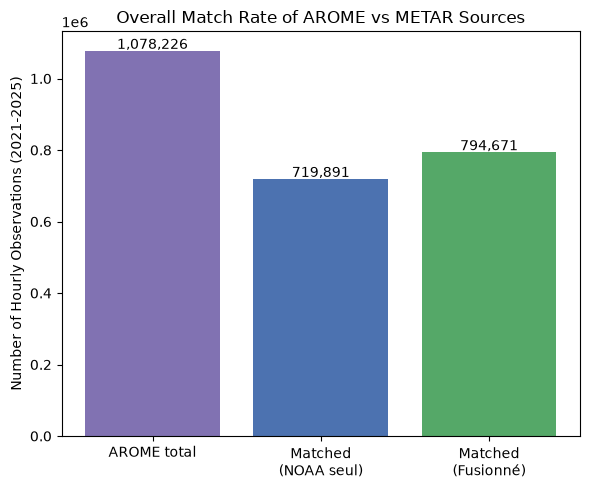

Overall match rate - NOAA alone : 66.8%
Overall match rate - Merged : 73.7%
Net gain from merging sources : +74,780 lines


In [3]:
n_arome = len(arome)
n_matched_noaa = matched_noaa.sum()
n_matched_merged = matched_merged.sum()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    ["AROME total", "Matched\n(NOAA seul)", "Matched\n(Fusionné)"],
    [n_arome, n_matched_noaa, n_matched_merged],
    color=["#8172B2", "#4C72B0", "#55A868"],
)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 5000, f"{int(b.get_height()):,}", ha="center")
ax.set_ylabel("Number of Hourly Observations (2021-2025)")
ax.set_title("Overall Match Rate of AROME vs METAR Sources")
plt.tight_layout()
plt.show()

print(f"Overall match rate - NOAA alone : {n_matched_noaa / n_arome * 100:.1f}%")
print(f"Overall match rate - Merged : {n_matched_merged / n_arome * 100:.1f}%")
print(f"Net gain from merging sources : +{n_matched_merged - n_matched_noaa:,} lines")

The overall AROME-METAR match rate improved from using the NOAA-only source to the merged source, with the largest gains concentrated in the four stations identified earlier. This confirms that the bulletin source is not just filling raw METAR coverage gaps in the abstract, but is directly increasing the amount of usable fused data for the target stations.

## 8. Descriptive Statistics of the Final Merged AROME-METAR Dataset

With the fusion pipeline finalized (NOAA + bulletin METAR source, corrected join key, one observation per station-hour), this section characterizes the resulting dataset: the number of samples per station and per year, and the temporal continuity of the two extreme cases, the most and least densely sampled stations.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

MERGED_PATH = "../data/cleaned/AROME_METAR_merged_2021_2025.csv"
MAPPING_PATH = "../data/cleaned/isd_history_station_check.csv"

mapping = pd.read_csv(MAPPING_PATH, dtype=str)
id_to_name = dict(zip(mapping["id"], mapping["station_name"]))

df = pd.read_csv(MERGED_PATH, dtype={"id": str}, low_memory=False)
df["datetime"] = pd.to_datetime(df["datetime"])
df["year"] = df["datetime"].dt.year
df["label"] = df["id"] + " - " + df["id"].map(id_to_name).fillna("")

print(f"Total records : {len(df):,}")
print(f"Stations : {df['id'].nunique()}")
print(f"Period : {df['datetime'].min()} -> {df['datetime'].max()}")

Total records : 794,671
Stations : 26
Period : 2021-01-01 00:00:00 -> 2025-08-24 21:00:00


### 8.1 Samples per station

Total number of fused AROME-METAR records available for each of the 26 stations over the full 2021-2025 period.

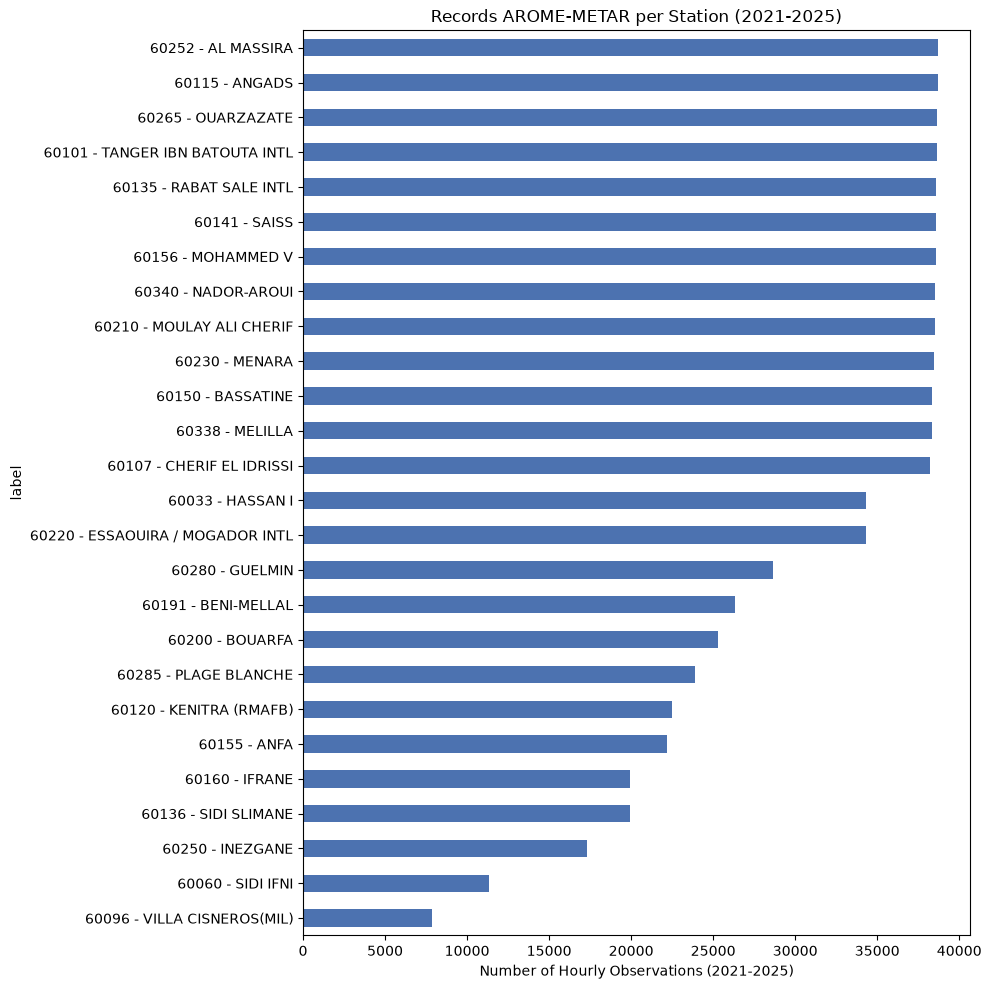

In [ ]:
per_station = df.groupby("label").size().sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
per_station.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Number of Hourly Observations (2021-2025)")
ax.set_title("Records AROME-METAR per Station (2021-2025)")
plt.tight_layout()
plt.show()

### 8.2 Samples per year, and per station/year jointly

The first plot aggregates sample counts by calendar year across all stations combined, to check for any systematic year-to-year drop (e.g. from a station going offline, or a change in the underlying data sources). The heatmap that follows breaks this down per station, which is necessary to distinguish a station-specific gap in a given year from a global one.

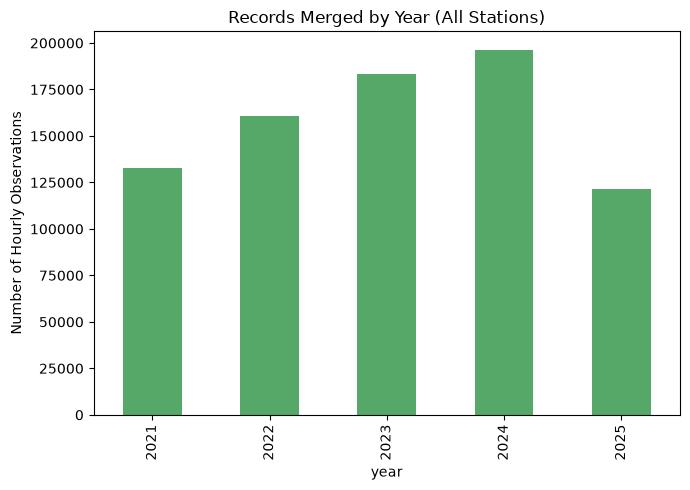

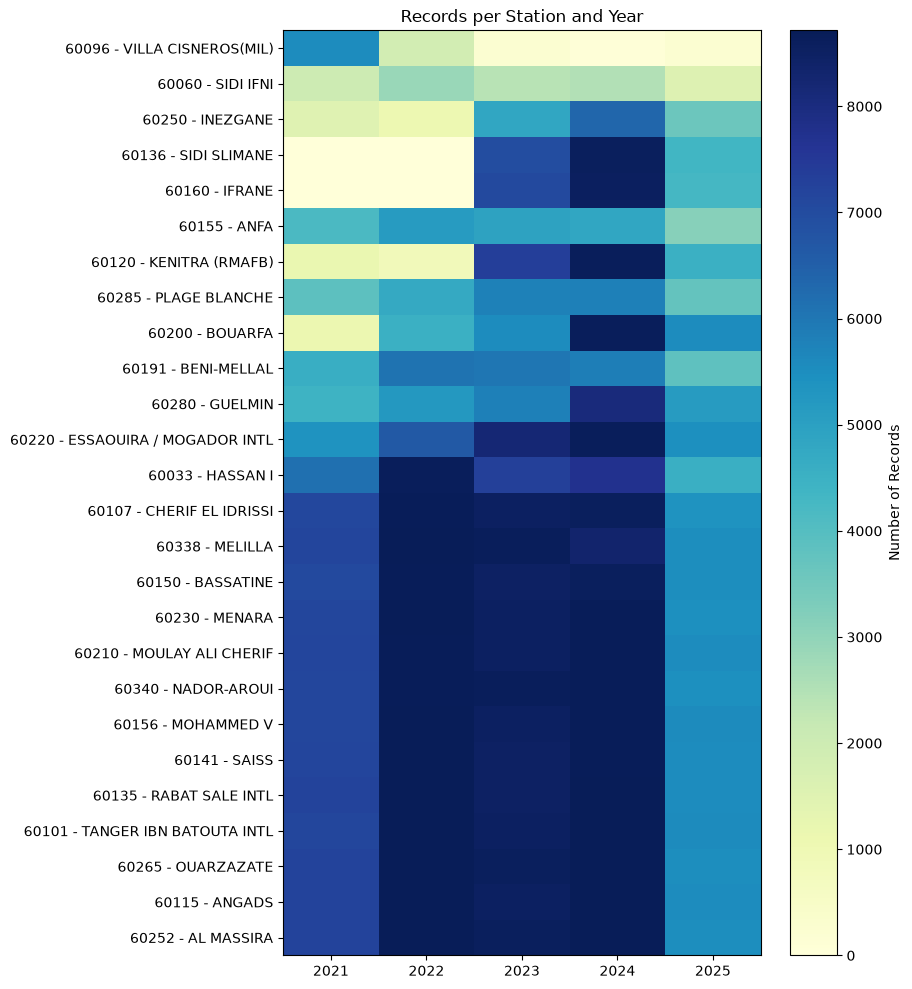

In [ ]:
per_year = df.groupby("year").size()

fig, ax = plt.subplots(figsize=(7, 5))
per_year.plot(kind="bar", ax=ax, color="#55A868")
ax.set_ylabel("Number of Hourly Observations")
ax.set_title("Records Merged by Year (All Stations)")
plt.tight_layout()
plt.show()

pivot = df.pivot_table(index="label", columns="year", aggfunc="size", fill_value=0)
pivot = pivot.loc[per_station.index] 

fig, ax = plt.subplots(figsize=(9, 10))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlGnBu")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_title("Records per Station and Year")
fig.colorbar(im, ax=ax, label="Number of Records")
plt.tight_layout()
plt.show()

### 8.3 Identifying the most and least densely sampled stations

These two stations are used as the basis for the continuity analysis that follows.

In [ ]:
most_recorded = per_station.idxmax()
least_recorded = per_station.idxmin()

print(f"Station the most recorded  : {most_recorded} ({per_station.max():,} records)")
print(f"Station the least recorded : {least_recorded} ({per_station.min():,} records)")

Station the most recorded  : 60252 - AL MASSIRA (38,721 records)
Station the least recorded : 60096 - VILLA CISNEROS(MIL) (7,861 records)


### 8.4 Temporal continuity: daily observation counts

Rather than relying on a single aggregate coverage percentage, this plots the number of observations per calendar day across the full period for both the most and least recorded stations. A station with genuinely continuous coverage should show a dense, roughly constant band close to the theoretical maximum of 24 hourly observations per day, while a station with real gaps will show visible empty or sparse stretches. This is a more direct diagnostic of data continuity than a single summary percentage, since two stations can have the same overall coverage rate while one has scattered isolated missing hours and the other has entire missing months.

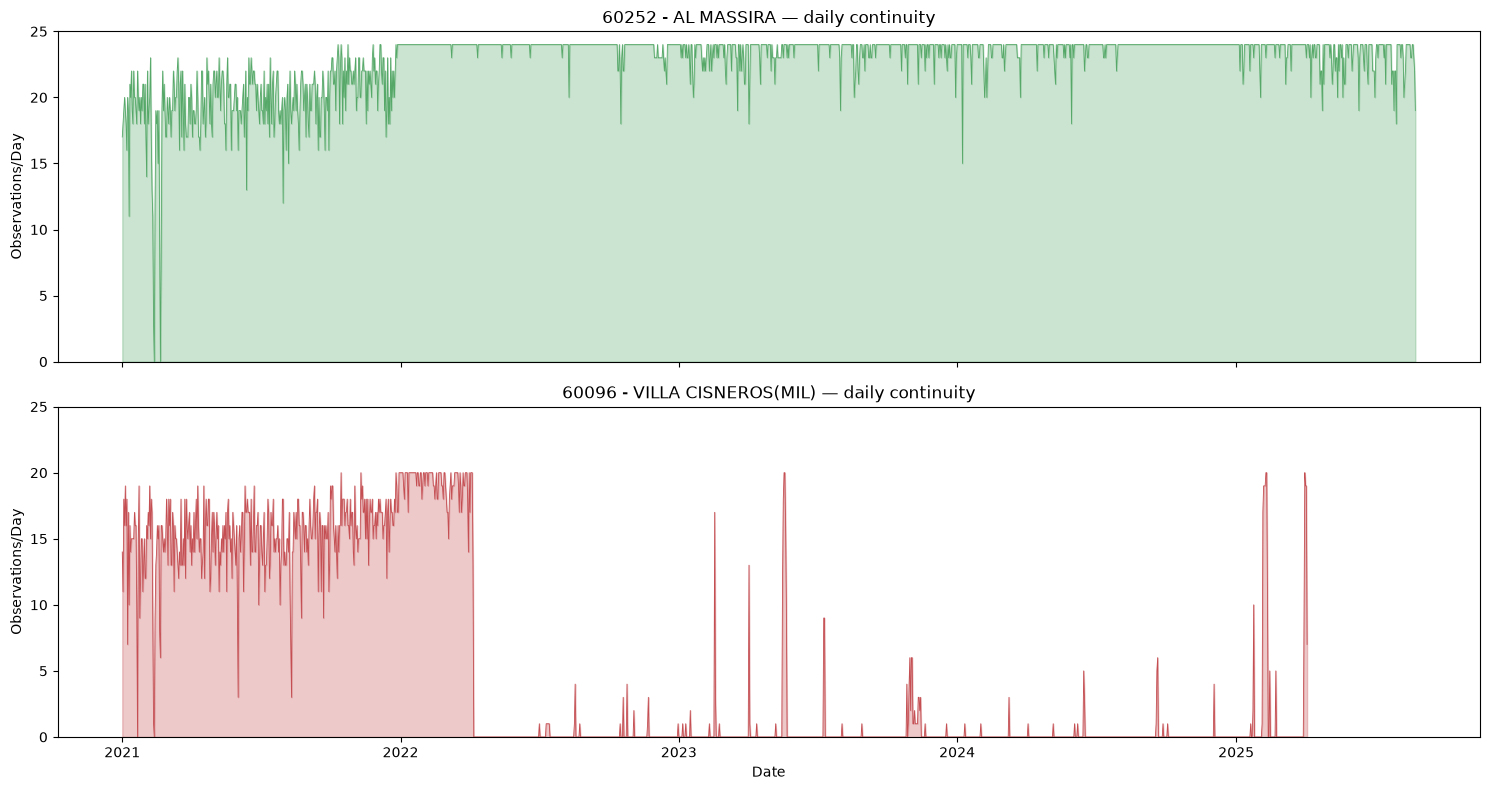

In [ ]:
def daily_counts(station_label):
    sub = df[df["label"] == station_label]
    return sub.set_index("datetime").resample("D").size()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

for ax, label, color in [
    (axes[0], most_recorded, "#55A868"),
    (axes[1], least_recorded, "#C44E52"),
]:
    counts = daily_counts(label)
    ax.plot(counts.index, counts.values, linewidth=0.6, color=color)
    ax.fill_between(counts.index, counts.values, color=color, alpha=0.3)
    ax.set_title(f"{label} : daily continuity")
    ax.set_ylabel("Observations/Day")
    ax.set_ylim(0, 25)  # max theoretical ~24 obs/Day (hourly)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()